In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
alpha = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180]
couple = [
        0.004280739365050996,
        -0.03277680934056946,
        -0.034985299696578605,
        -0.036984557912797075,
        -0.02999095986861159,
        0.033325901671470884,
        0.04571666640080625,
        0.040550431960137856,
        0.043070768044273566,
        -0.0007424838397296178
    ]

In [4]:
alpha = [
    0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 
    20.0, 22.0, 24.0, 26.0, 28.0, 30.0, 32.0, 34.0, 36.0, 38.0, 
    40.0, 42.0, 44.0, 46.0, 48.0, 50.0, 52.0, 54.0, 56.0, 58.0, 
    60.0, 62.0, 64.0, 66.0, 68.0, 70.0, 72.0, 74.0, 76.0, 78.0, 
    80.0, 82.0, 84.0, 86.0, 88.0, 90.0, 92.0, 94.0, 96.0, 98.0, 
    100.0, 102.0, 104.0, 106.0, 108.0, 110.0, 112.0, 114.0, 116.0, 118.0, 
    120.0, 122.0, 124.0, 126.0, 128.0, 130.0, 132.0, 134.0, 136.0, 138.0, 
    140.0, 142.0, 144.0, 146.0, 148.0, 150.0, 152.0, 154.0, 156.0, 158.0, 
    160.0, 162.0, 164.0, 166.0, 168.0, 170.0, 172.0, 174.0, 176.0, 178.0, 
    180.0, 182.0, 184.0, 186.0, 188.0, 190.0
]

couple = [
    0.007691975878, -0.004467383974, -0.012247866064, -0.022106772312, -0.026442852951,
    -0.027057405726, -0.025102569267, -0.027600743331, -0.024794567056, -0.029822690833,
    -0.030851582802, -0.040538583103, -0.037989593097, -0.043880512456, -0.046414659153,
    -0.040026869957, -0.047192960992, -0.042128649895, -0.046743306671, -0.039912065291,
    -0.037482420113, -0.039109998432, -0.035662239044, -0.034577451882, -0.029764236132,
    -0.040664485076, -0.041327031892, -0.043108500455, -0.042866521323, -0.045482136365,
    -0.04630736373, -0.042548999984, -0.037174811703, -0.041144875609, -0.033642266316,
    -0.033048894676, -0.031253801611, -0.033035981107, -0.031007985706, -0.035986510414,
    -0.037182360407, -0.026211247929, -0.021881889318, -0.019267837147, -0.006881155819,
    0.001464246952, 0.014029358141, 0.022888733453, 0.021720430199, 0.030930925634,
    0.031614012595, 0.036344609344, 0.036512627193, 0.035939261307, 0.043553255365,
    0.039062587284, 0.038630006195, 0.044806495948, 0.05572049553, 0.050246154558,
    0.050913394126, 0.048886902085, 0.052255761043, 0.049914385864, 0.050700938421,
    0.04570899534, 0.041309043293, 0.040815438514, 0.04428721383, 0.040006765062,
    0.044289154512, 0.045344725551, 0.049318906423, 0.052909068903, 0.046977999834,
    0.050295946626, 0.05354347533, 0.048311147631, 0.046784824519, 0.041219047612,
    0.034807262455, 0.032357548729, 0.035791939471, 0.037583706513, 0.029358361378,
    0.034243819127, 0.02823221437, 0.026254878949, 0.019172197336, 0.010505947798,
    0.000076478672, -0.008656769824, -0.011509229606, -0.02184599165, -0.023632404739,
    -0.031044847331
]

In [5]:
def sin_model(x, A, B, C, D):
    return A * np.sin(B*np.radians(x) + C) + D

In [6]:
fit_sin, cov_h = curve_fit(sin_model, alpha, couple)

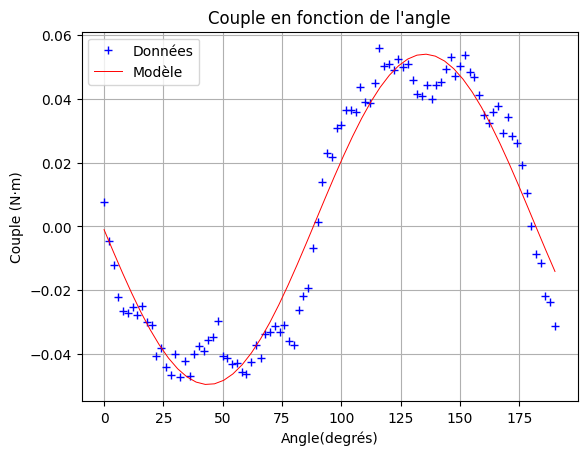

In [7]:
plt.plot(alpha, couple,'+', color='b', label='Données')
plt.plot(np.linspace(min(alpha), max(alpha)), sin_model(np.linspace(min(alpha), max(alpha)), *fit_sin), color='r', label='Modèle', lw=0.7)
plt.title('Couple en fonction de l\'angle')
plt.xlabel('Angle(degrés)')
plt.ylabel('Couple (N·m)')
plt.grid(True)
plt.legend()
plt.show()

In [8]:
import numpy as np
from scipy.optimize import curve_fit

# Conversion des listes en arrays numpy
x_data = np.array(alpha)
y_data = np.array(couple)

# Définition de la fonction (Modèle avec harmonique 1 et 3)
def model_fourier(theta, a1, a3, p, phi):
    # p est le nombre de paires de pôles, souvent fixe selon ta géométrie
    rad = np.radians(theta)
    return a1 * np.sin(p * rad + phi) + a3 * np.sin(3 * p * rad + phi)

# Ajustement (p=2 semble correspondre à un cycle de 180°)
params, _ = curve_fit(model_fourier, x_data, y_data, p0=[0.05, 0.005, 2, 0])

print(f"Amplitude fondamentale : {params[0]:.4f}")
print(f"Amplitude harmonique 3 : {params[1]:.4f}")

Amplitude fondamentale : -0.0518
Amplitude harmonique 3 : -0.0101


Paramètres identifiés :
Amplitude Fondamentale (A1) : -0.05182 N.m
Amplitude Harmonique 3 (A3) : -0.01012 N.m


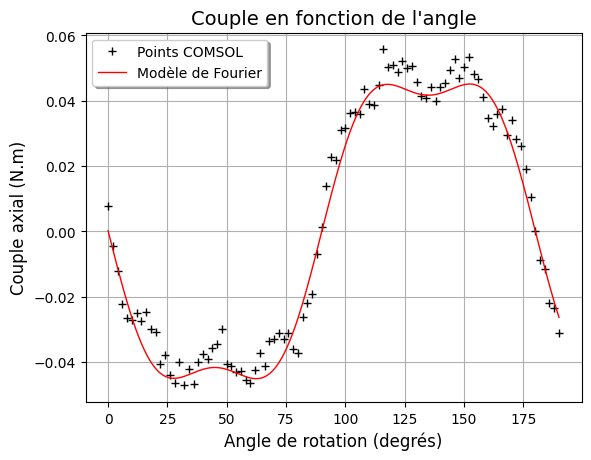

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Tes données COMSOL
angles = np.array([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0, 32.0, 34.0, 36.0, 38.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0, 52.0, 54.0, 56.0, 58.0, 60.0, 62.0, 64.0, 66.0, 68.0, 70.0, 72.0, 74.0, 76.0, 78.0, 80.0, 82.0, 84.0, 86.0, 88.0, 90.0, 92.0, 94.0, 96.0, 98.0, 100.0, 102.0, 104.0, 106.0, 108.0, 110.0, 112.0, 114.0, 116.0, 118.0, 120.0, 122.0, 124.0, 126.0, 128.0, 130.0, 132.0, 134.0, 136.0, 138.0, 140.0, 142.0, 144.0, 146.0, 148.0, 150.0, 152.0, 154.0, 156.0, 158.0, 160.0, 162.0, 164.0, 166.0, 168.0, 170.0, 172.0, 174.0, 176.0, 178.0, 180.0, 182.0, 184.0, 186.0, 188.0, 190.0])
couples = np.array([0.007691975878, -0.004467383974, -0.012247866064, -0.022106772312, -0.026442852951, -0.027057405726, -0.025102569267, -0.027600743331, -0.024794567056, -0.029822690833, -0.030851582802, -0.040538583103, -0.037989593097, -0.043880512456, -0.046414659153, -0.040026869957, -0.047192960992, -0.042128649895, -0.046743306671, -0.039912065291, -0.037482420113, -0.039109998432, -0.035662239044, -0.034577451882, -0.029764236132, -0.040664485076, -0.041327031892, -0.043108500455, -0.042866521323, -0.045482136365, -0.04630736373, -0.042548999984, -0.037174811703, -0.041144875609, -0.033642266316, -0.033048894676, -0.031253801611, -0.033035981107, -0.031007985706, -0.035986510414, -0.037182360407, -0.026211247929, -0.021881889318, -0.019267837147, -0.006881155819, 0.001464246952, 0.014029358141, 0.022888733453, 0.021720430199, 0.030930925634, 0.031614012595, 0.036344609344, 0.036512627193, 0.035939261307, 0.043553255365, 0.039062587284, 0.038630006195, 0.044806495948, 0.05572049553, 0.050246154558, 0.050913394126, 0.048886902085, 0.052255761043, 0.049914385864, 0.050700938421, 0.04570899534, 0.041309043293, 0.040815438514, 0.04428721383, 0.040006765062, 0.044289154512, 0.045344725551, 0.049318906423, 0.052909068903, 0.046977999834, 0.050295946626, 0.05354347533, 0.048311147631, 0.046784824519, 0.041219047612, 0.034807262455, 0.032357548729, 0.035791939471, 0.037583706513, 0.029358361378, 0.034243819127, 0.02823221437, 0.026254878949, 0.019172197336, 0.010505947798, 0.000076478672, -0.008656769824, -0.011509229606, -0.02184599165, -0.023632404739, -0.031044847331])

# 2. Définition du modèle (Série de Fourier : Fondamental + Harmonique 3)
def modele_torque(theta_deg, A1, A3, phi):
    theta_rad = np.radians(theta_deg)
    # p=2 ici car on a un cycle complet sur 180°
    return A1 * np.sin(2 * theta_rad + phi) + A3 * np.sin(6 * theta_rad + phi)

# 3. Calcul du "Fit" (optimisation des paramètres)
params, _ = curve_fit(modele_torque, angles, couples, p0=[0.05, 0.01, 0])
A1_fit, A3_fit, phi_fit = params

# Génération de la courbe lisse pour le modèle
angles_lisses = np.linspace(0, 190, 500)
couples_fit = modele_torque(angles_lisses, *params)

# Points COMSOL
plt.plot(angles, couples, 'k+', label='Points COMSOL')

# Courbe théorique ajustée
plt.plot(angles_lisses, couples_fit, color='red', linewidth=1, label='Modèle de Fourier')

# Habillage et annotations
plt.title("Couple en fonction de l'angle", fontsize=14)
plt.xlabel("Angle de rotation (degrés)", fontsize=12)
plt.ylabel("Couple axial (N.m)", fontsize=12)
plt.grid(True)

# Zone d'ombre pour visualiser l'erreur (résidus)

plt.legend(loc='upper left', frameon=True, shadow=True)


print(f"Paramètres identifiés :")
print(f"Amplitude Fondamentale (A1) : {A1_fit:.5f} N.m")
print(f"Amplitude Harmonique 3 (A3) : {A3_fit:.5f} N.m")

plt.show()

In [10]:
#je veux connaitre la position du maximum du couple et la valeur du couple maximum
max_index = np.argmax(couple)
angles[58]

116.0

In [11]:
# Distance en mm
distance = [5, 10, 15, 20, 25, 30]

# Couple de torsion axial (N·m)
torque = [
    0.10022116456759611, 
    0.04826365411367627, 
    0.026798020444001175, 
    0.016949083302528336, 
    0.011670729918629169, 
    0.0002534897133909114
]

In [12]:
def model_torque_distance(d, A, B):
    return A/d**B

fit_distance, _ = curve_fit(model_torque_distance, distance, torque)
A_fit, B_fit = fit_distance
print(f"Paramètres du modèle de distance : A = {A_fit:.4f}, B = {B_fit:.4f}")

Paramètres du modèle de distance : A = 0.7945, B = 1.2760


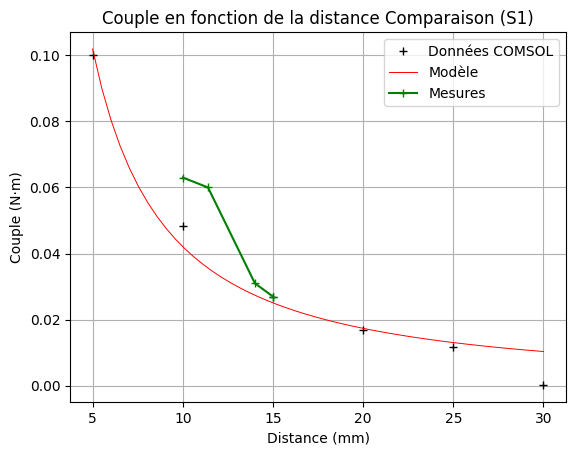

In [13]:
d=[10, 11.4,14, 15]
C_max=[0.063, 0.06, 0.031, 0.027]

plt.plot(distance, torque,'+', color='k', label='Données COMSOL')
plt.plot(np.linspace(min(distance), max(distance)), model_torque_distance(np.linspace(min(distance), max(distance)), *fit_distance), color='r', label='Modèle', lw=0.7)
plt.plot(d, C_max,'+-', color='g', label='Mesures')
plt.title('Couple en fonction de la distance Comparaison (S1)')
plt.xlabel('Distance (mm)')
plt.ylabel('Couple (N·m)')
plt.grid(True)
plt.legend()
plt.show()

système 2

In [14]:
angles = [
    0, 8, 16, 24.000000000000004, 32, 40, 48.00000000000001, 56, 64, 72, 80, 88, 
    96.00000000000001, 104, 112, 119.99999999999999, 128, 136, 144, 152, 160, 
    168, 176, 184, 192.00000000000003, 200, 208, 216, 224, 232.00000000000003, 
    239.99999999999997, 248, 256, 264, 272, 280, 288, 296, 304, 312, 320, 328, 
    336, 344, 352, 360
]

couple = [
    -0.01146708804722325, -0.026977509554831122, -0.012718410209240787, 
    -0.0170241058808995, -0.02486724782337869, -0.01015531967335814, 
    -0.03150381565952612, -0.015981287659134757, -0.02302703304555578, 
    -0.015459447649100802, -0.012652509994948428, -0.014985799170556265, 
    -0.010133321455826606, -0.019675880727077585, -0.02267483789938505, 
    -0.019215325771354777, -0.02103112859370556, -0.01910566219608107, 
    -0.013241655071352443, -0.02246711848970242, -0.014114453508008253, 
    -0.018623817121400273, -0.003274104906275572, 0.007870044451378039, 
    0.019023587873575297, 0.015781037196895283, 0.02307814926160067, 
    0.020850739815213654, 0.017379785094235652, 0.02294118812770886, 
    0.01761048854820573, 0.021170242872382786, 0.01605933705609703, 
    0.015200592082993764, 0.009118819849253244, 0.011698954808437079, 
    0.02031850713397642, 0.018721048994111637, 0.015059185730424314, 
    0.023235904451556648, 0.01579301644342943, 0.019073685645503935, 
    0.02350477799607585, 0.02515737696520223, 0.020262394096856227, 
    0.0010509046877983722
]

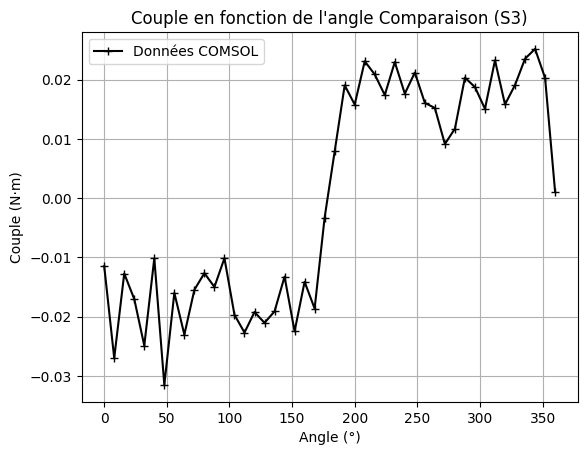

In [19]:
plt.plot(angles, couple,'+-', color='k', label='Données COMSOL')
#plt.plot(np.linspace(min(angles), max(angles)), model_torque_angles(np.linspace(min(angles), max(angles)), *fit_angles), color='r', label='Modèle', lw=0.7)
plt.title('Couple en fonction de l\'angle Comparaison (S3)')
plt.xlabel('Angle (°)')
plt.ylabel('Couple (N·m)')
plt.grid(True)
plt.legend()
plt.show()